In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [2]:
!mkdir -p diagrams/generator-study/

In [3]:
# ----------------------------
# Generators & stages (Stage-0 is shared baseline; not plotted as bars)
# ----------------------------
generators = ["DeepSeek", "GPT-4.1","LLAMA-1B"]
stages_shown = ["Stage-2"]  # bars per generator

# ----------------------------
# K=5 values FROM YOUR TABLE
# ----------------------------
# DeepSeek (DS)
#   Stage-1-POS: NDCG@5=0.2641, PopRate@5=0.2982
# GPT-4.1 (GPT)
#   Stage-1-POS: NDCG@5=0.2466, PopRate@5=0.2813

ndcg5 = {
    "DeepSeek": [0.2641], # , 0.2400],
    "GPT-4.1":  [0.2466], # , 0.2516],
    "LLAMA-1B": [0.2071], #, 0.2604]
}
pr5 = {
    "DeepSeek": [0.2982], # , 0.3088],
    "GPT-4.1":  [0.2813], # , 0.2643],
    "LLAMA-1B": [0.3552], # , 0.3439],
}

# ----------------------------
# Shared Stage-0 baseline at K=5
# LLaMA-Stage-0 @ K=5: NDCG=0.1863, PopRate=0.3858
# ----------------------------
stage0_ndcg5 = 0.1863
stage0_pr5   = 0.3858
DIR_NAME = "diagrams/generator-study"

In [4]:
# ----------------------------
# Helper: grouped bars + shared Stage-0 baseline line
# ----------------------------
def plot_generators_with_baseline(metric_dict, baseline_value, title, ylabel, filename=None, lower_is_better=False):
    x = np.arange(len(generators))           # groups = generators
    width = 0.8 / len(stages_shown)          # bar width within each group
    
    fig, ax = plt.subplots(figsize=(10,5))
    
    # NEW: per-generator colors (Tableau/CB-safe)
    gen_colors = {
        "LLaMA-1B": "#4C72B0",
        "DeepSeek": "#55A868",
        "GPT-4.1":  "#C44E52",
    }
    # Stage shading: Stage-1 lighter, Final darker
    stage_alphas = [1.00]
    
    base_color = "#E17C24"
    all_vals= []

    # --- CHANGED BLOCK: draw bars with color per generator ---
    for gi, gen in enumerate(generators):
        for si, stage in enumerate(stages_shown):
            val = metric_dict[gen][si]
            all_vals.append(val)
            xpos = x[gi] + si*width - (len(stages_shown)-1)*width/2
            ax.bar(
                xpos,
                val,
                width,
                label=stage if gi == 0 else None,  # add stage labels once
                color=gen_colors.get(gen, "#4C72B0"),
                alpha=stage_alphas[min(si, len(stage_alphas)-1)],
                edgecolor=gen_colors.get(gen, "#4C72B0"),
                linewidth=0.8
            )

    
    
    # Shared Stage-0 baseline
    ax.axhline(
        baseline_value,
        linestyle="--",
        linewidth=1.5,
        color=base_color,
        label="Stage-1 (shared)"
    )
    
    # y padding based on tallest element (bar or baseline)
    ymax_raw = max(all_vals + [baseline_value])
    ypad = max(0.02, 0.08 * ymax_raw)  # 8% headroom (>= 0.02)
    ax.set_ylim(0, ymax_raw + ypad)
    
    
    # annotate baseline near the right edge
    ax.text(
        x[-1] + 0.55, baseline_value,
        f"Stage-1: {baseline_value:.3f}",
        va="center", ha="left", fontsize=15, color=base_color
    )

    # Axes & labels
    ax.set_xticks(x)
    ax.set_xticklabels(generators, fontsize=18)
    ax.set_ylabel(
        ylabel + (" (lower is better)" if lower_is_better else " (higher is better)"),
        fontsize=18
    )
    ax.set_title(title, fontsize=20, fontweight='bold')
    ax.tick_params(axis='y', labelsize=15)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # Legend: stages + baseline (stage labels added only once above)

    legend_handles = [
            Patch(facecolor=gen_colors.get("LLaMA-1B"), label="LLaMA-1B"),
            Patch(facecolor=gen_colors.get("DeepSeek"), label="DeepSeek"),
            Patch(facecolor=gen_colors.get("GPT-4.1"),  label="GPT-4.1"),
            Line2D([0],[0], color=base_color, linestyle="--", linewidth=2, label="Stage-1 (shared)")
        ]
    ax.legend(
        handles=legend_handles,
        title="Condition",
        fontsize=13, title_fontsize=15,
        loc="upper right", bbox_to_anchor=(1.45, 0.6) if not lower_is_better else (1.45,0.85)
    )

    # Value labels on bars
    for gi, gen in enumerate(generators):
        for si, stage in enumerate(stages_shown):
            val = metric_dict[gen][si]
            xi = x[gi] + si*width - (len(stages_shown)-1)*width/2
            ax.text(xi, val, f"{val:.3f}", ha="center", va="bottom", fontsize=15)

    fig.tight_layout()
    if filename:
        plt.savefig(filename, dpi=200, bbox_inches="tight")
        
    plt.show()
    plt.close(fig)
    return

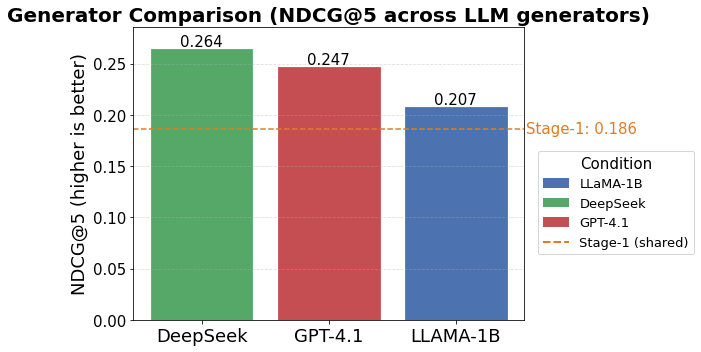

In [5]:
# ----------------------------
# Generate the two K=5 charts
# ----------------------------
plot_generators_with_baseline(
    ndcg5,
    baseline_value=stage0_ndcg5,
    title="Generator Comparison (NDCG@5 across LLM generators)",
    ylabel="NDCG@5",
    filename=f"{DIR_NAME}/generators_k5_ndcg5.png"
)



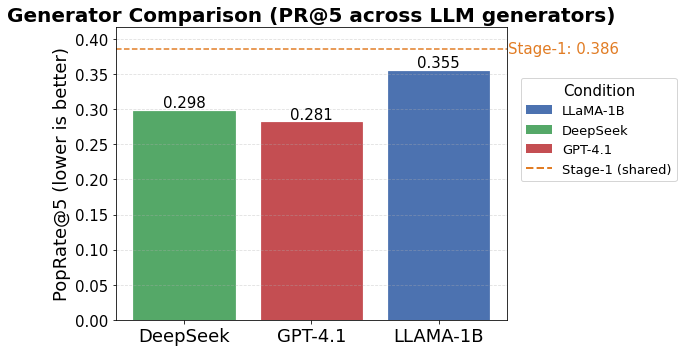

In [6]:
plot_generators_with_baseline(
    pr5,
    baseline_value=stage0_pr5,
    title="Generator Comparison (PR@5 across LLM generators)",
    ylabel="PopRate@5",
    filename=f"{DIR_NAME}/generators_k5_pr5.png",
    lower_is_better=True
)